In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score, roc_curve

In [3]:
#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




#setting filepaths the datasets

pi_results_filepath_ml = "../prediction_results/PI_results/benchmarkings/PI_"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/benchmarkings/NNRTI_"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/benchmarkings/NRTI_"

ini_results_filepath_ml = "../prediction_results/INI_results/benchmarkings/INI_"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]



PI_MuLaTabICL_full_model_step-1000.ckpt_probabilities_5_fold.csv
ROC AUC:  0.5474582996541834


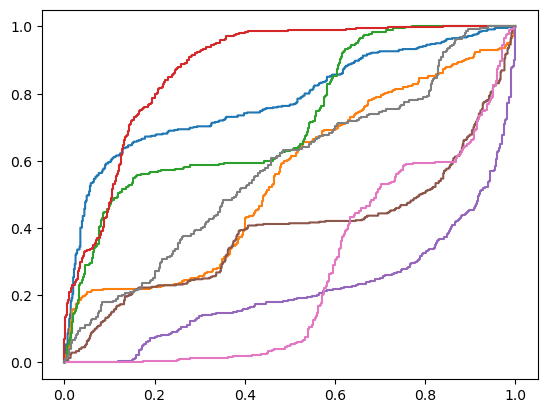

PI_MuLaTabICL_full_model_step-1000_probabilities_5_foldnew_loss.csv
ROC AUC:  0.8916280507619263


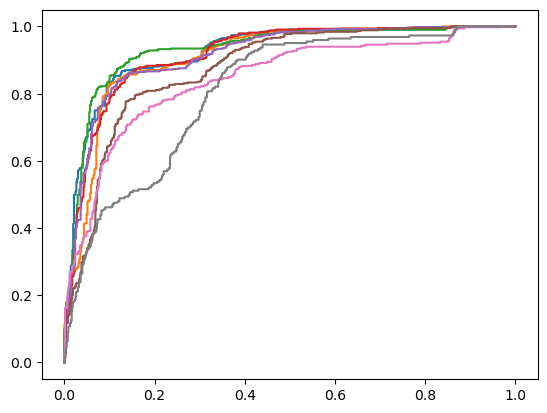

PI_MuLaTabICL_full_model_step-1000_probabilities_5_fold_new_loss_average_logits.csv
ROC AUC:  0.9078545108651965


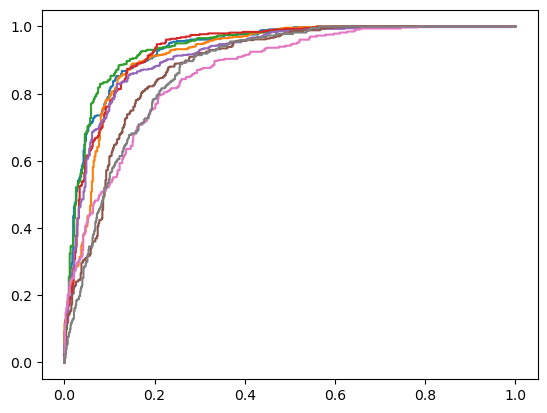

PI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv
ROC AUC:  0.9779292708733489


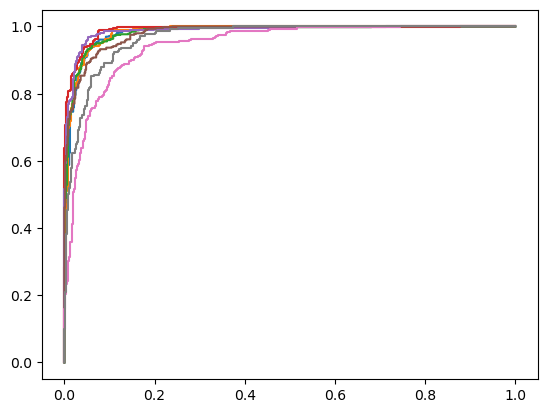

In [5]:
files= ["../prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000.ckpt_probabilities_5_fold.csv","../prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_foldnew_loss.csv", "../prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_fold_new_loss_average_logits.csv", "../prediction_results/PI_results/PI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

for file in files:

    print(file.split("/")[-1])
    df = pd.read_csv(file)


    true_labels = df.filter(regex="True_*")
    pred_proba = df.filter(regex="Pred_*")

    true_label_arr = np.array(true_labels)
    pred_proba_arr = np.array(pred_proba)

    fig, ax = plt.subplots()

    for r in range(true_label_arr.shape[1]):
        fpr, tpr, thresholds = roc_curve(true_label_arr[:,r], pred_proba_arr[:,r], pos_label=1)

        ax.plot(fpr, tpr)

    print("ROC AUC: ",roc_auc_score(true_labels, pred_proba))
    plt.show()


============PI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============NNRTI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============NRTI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============INI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1


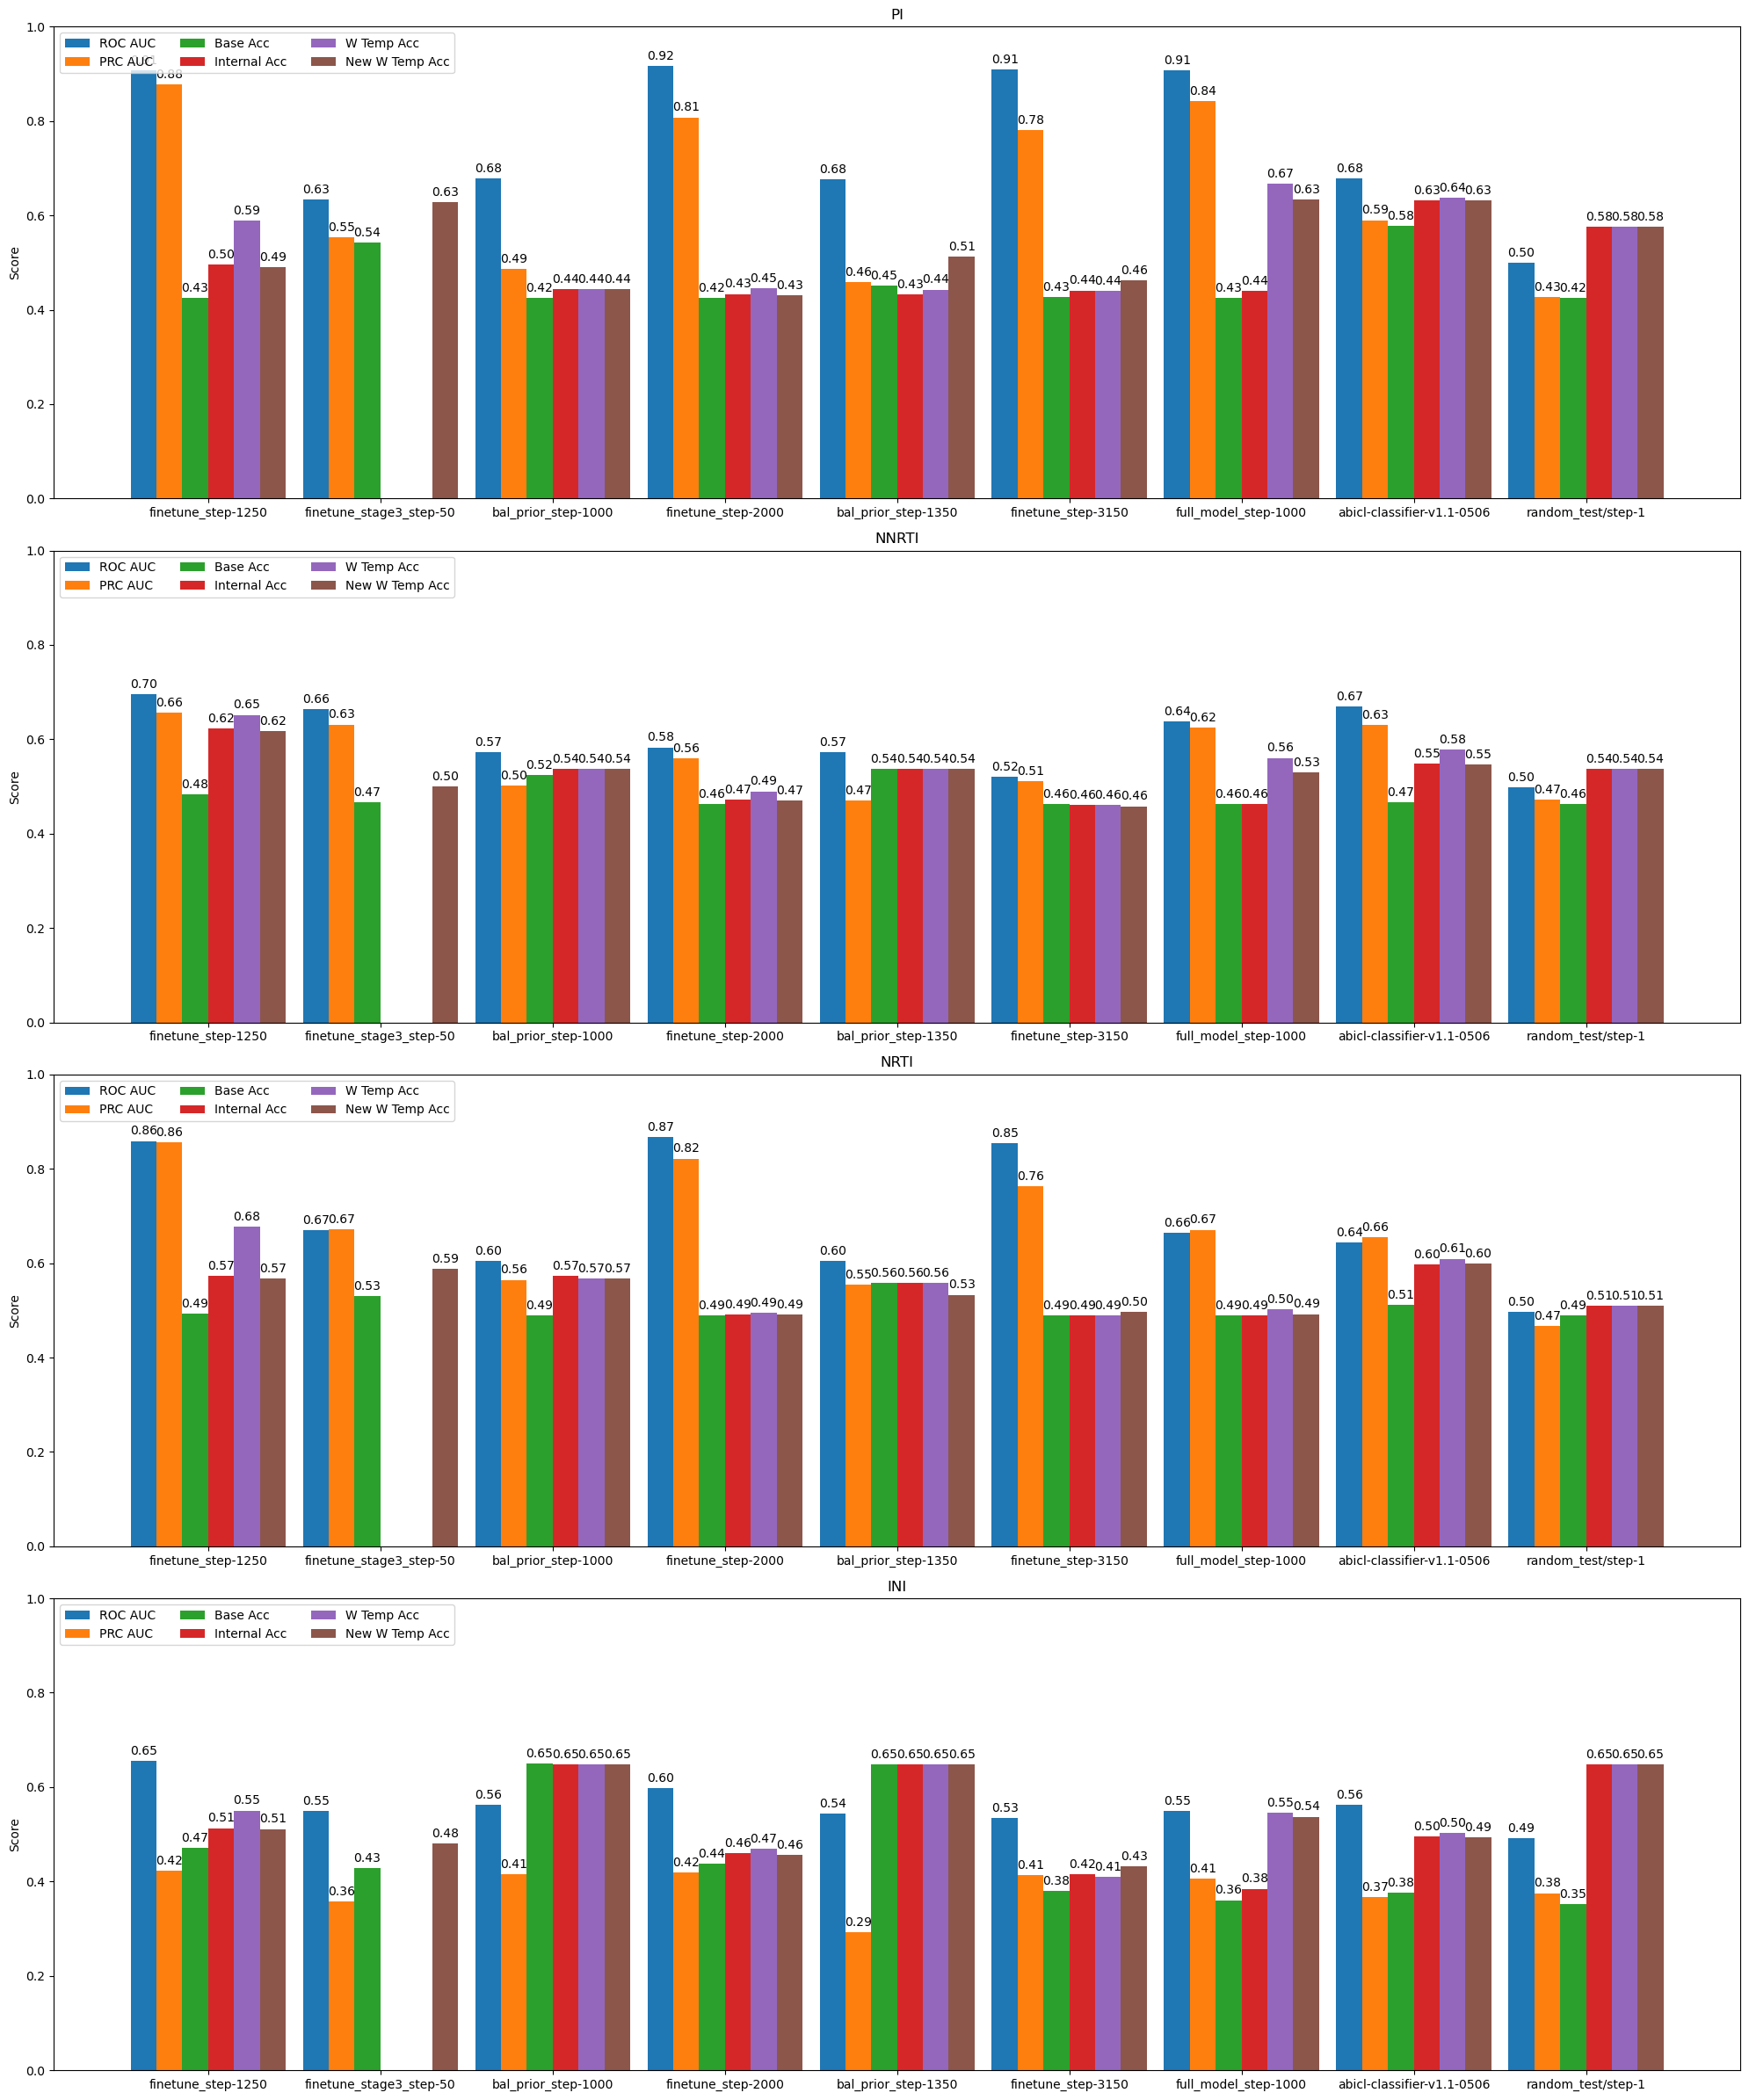

In [9]:
modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_stage3_step-50",
    "bal_prior_step-1000",
    "finetune_step-2000",
    "bal_prior_step-1350",
    "finetune_step-3150",
    "full_model_step-1000",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]

ending = "_5_fold_new_loss_sigmoid.csv"

thrshlds_internal = {"finetune_step-1250":  0.6860411,
"bal_prior_step-1000":  0.5292327,
"finetune_step-2000":  0.747135,
"bal_prior_step-1350":  0.504576,
"finetune_step-3150":  0.67952967,
"full_model_step-1000":  0.581367369,
"abicl-classifier-v1.1-0506":  0.709058,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig = {"finetune_step-1250":  0.7540253,
"bal_prior_step-1000":  0.52958435,
"finetune_step-2000":  0.79760474,
"bal_prior_step-1350":  0.5100705,
"finetune_step-3150":  0.67292804,
"full_model_step-1000":  0.748620175,
"abicl-classifier-v1.1-0506":  0.7361159,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig_new = {"finetune_step-1250":  0.6830695,
"finetune_stage3_step-50":  0.62230235,
"bal_prior_step-1000":  0.53245866,
"finetune_step-2000":  0.721869,
"bal_prior_step-1350":  0.5226037,
"finetune_step-3150":  0.82249993,
"full_model_step-1000":  0.73285752,
"abicl-classifier-v1.1-0506":  0.7113368,
"random_test/step-1":  np.nan,}

results = []


for path in filepath_list:



    roc_auc = []
    prc_auc = []
    old_acc = []
    exac_int = []
    exac_tmp = []
    exac_new = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred = pd.read_csv(path + modeltype + model + ending)
        pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

        true_labels = pred.filter(regex="True_*")
        pred_labels_old = pred.filter(regex="Pred_*")
        pred_proba = pred_proba.filter(regex="Pred_*")
        #print(max(pred_proba.max()), min(pred_proba.min()))

        true_label_arr = np.array(true_labels)
        pred_proba_arr = np.array(pred_proba)

        roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))

        old_acc.append(result_handler.exam_acc(pred_labels_old, true_labels))

        if model in list(thrshlds_internal.keys()):
            pred_labels_new = (pred_proba > thrshlds_internal[model]) * 1.0

            exac_int.append(result_handler.exam_acc(pred_labels_new, true_labels))
        else:
            exac_int.append(np.nan)

        if model in list(thrshlds_temp_sig.keys()):
            pred_labels_new = (pred_proba > thrshlds_temp_sig[model]) * 1.0

            exac_tmp.append(result_handler.exam_acc(pred_labels_new, true_labels))
        else:
            exac_tmp.append(np.nan)

        pred_labels_new = (pred_proba > thrshlds_temp_sig_new[model]) * 1.0

        exac_new.append(result_handler.exam_acc(pred_labels_new, true_labels))


    model_results= {"ROC AUC":roc_auc,
                                 "PRC AUC":prc_auc,
                                 "Base Acc": old_acc,
                                 "Internal Acc":exac_int,
                                 "W Temp Acc":exac_tmp,
                                 "New W Temp Acc":exac_new}

    results.append(model_results)


x = np.arange(len(models))  # the label locations
width = 0.15  # the width of the bars

fig, axs = plt.subplots(4, figsize=(20, 24),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = -1.5

    ax = axs[i]

    for attribute, measurement in results[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, fmt='%.2f', padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.set_xticks(x + width, models)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)

plt.show()

============PI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
../prediction_results/PI_results/benchmarkings/PI_BR_XGB_probabilities.csv
../prediction_results/PI_results/benchmarkings/PI_CC_XGB_probabilities.csv
../prediction_results/PI_results/PI_Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv
../prediction_results/PI_results/PI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv
============NNRTI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
../prediction_results/NNRTI_results/benchmarkings/NNRTI_BR_XGB_probabilities.csv
../prediction_results/NNRTI_results/benchmarkings/NNRTI_CC_XGB_probabilities.csv
../prediction_results/NNRTI_results

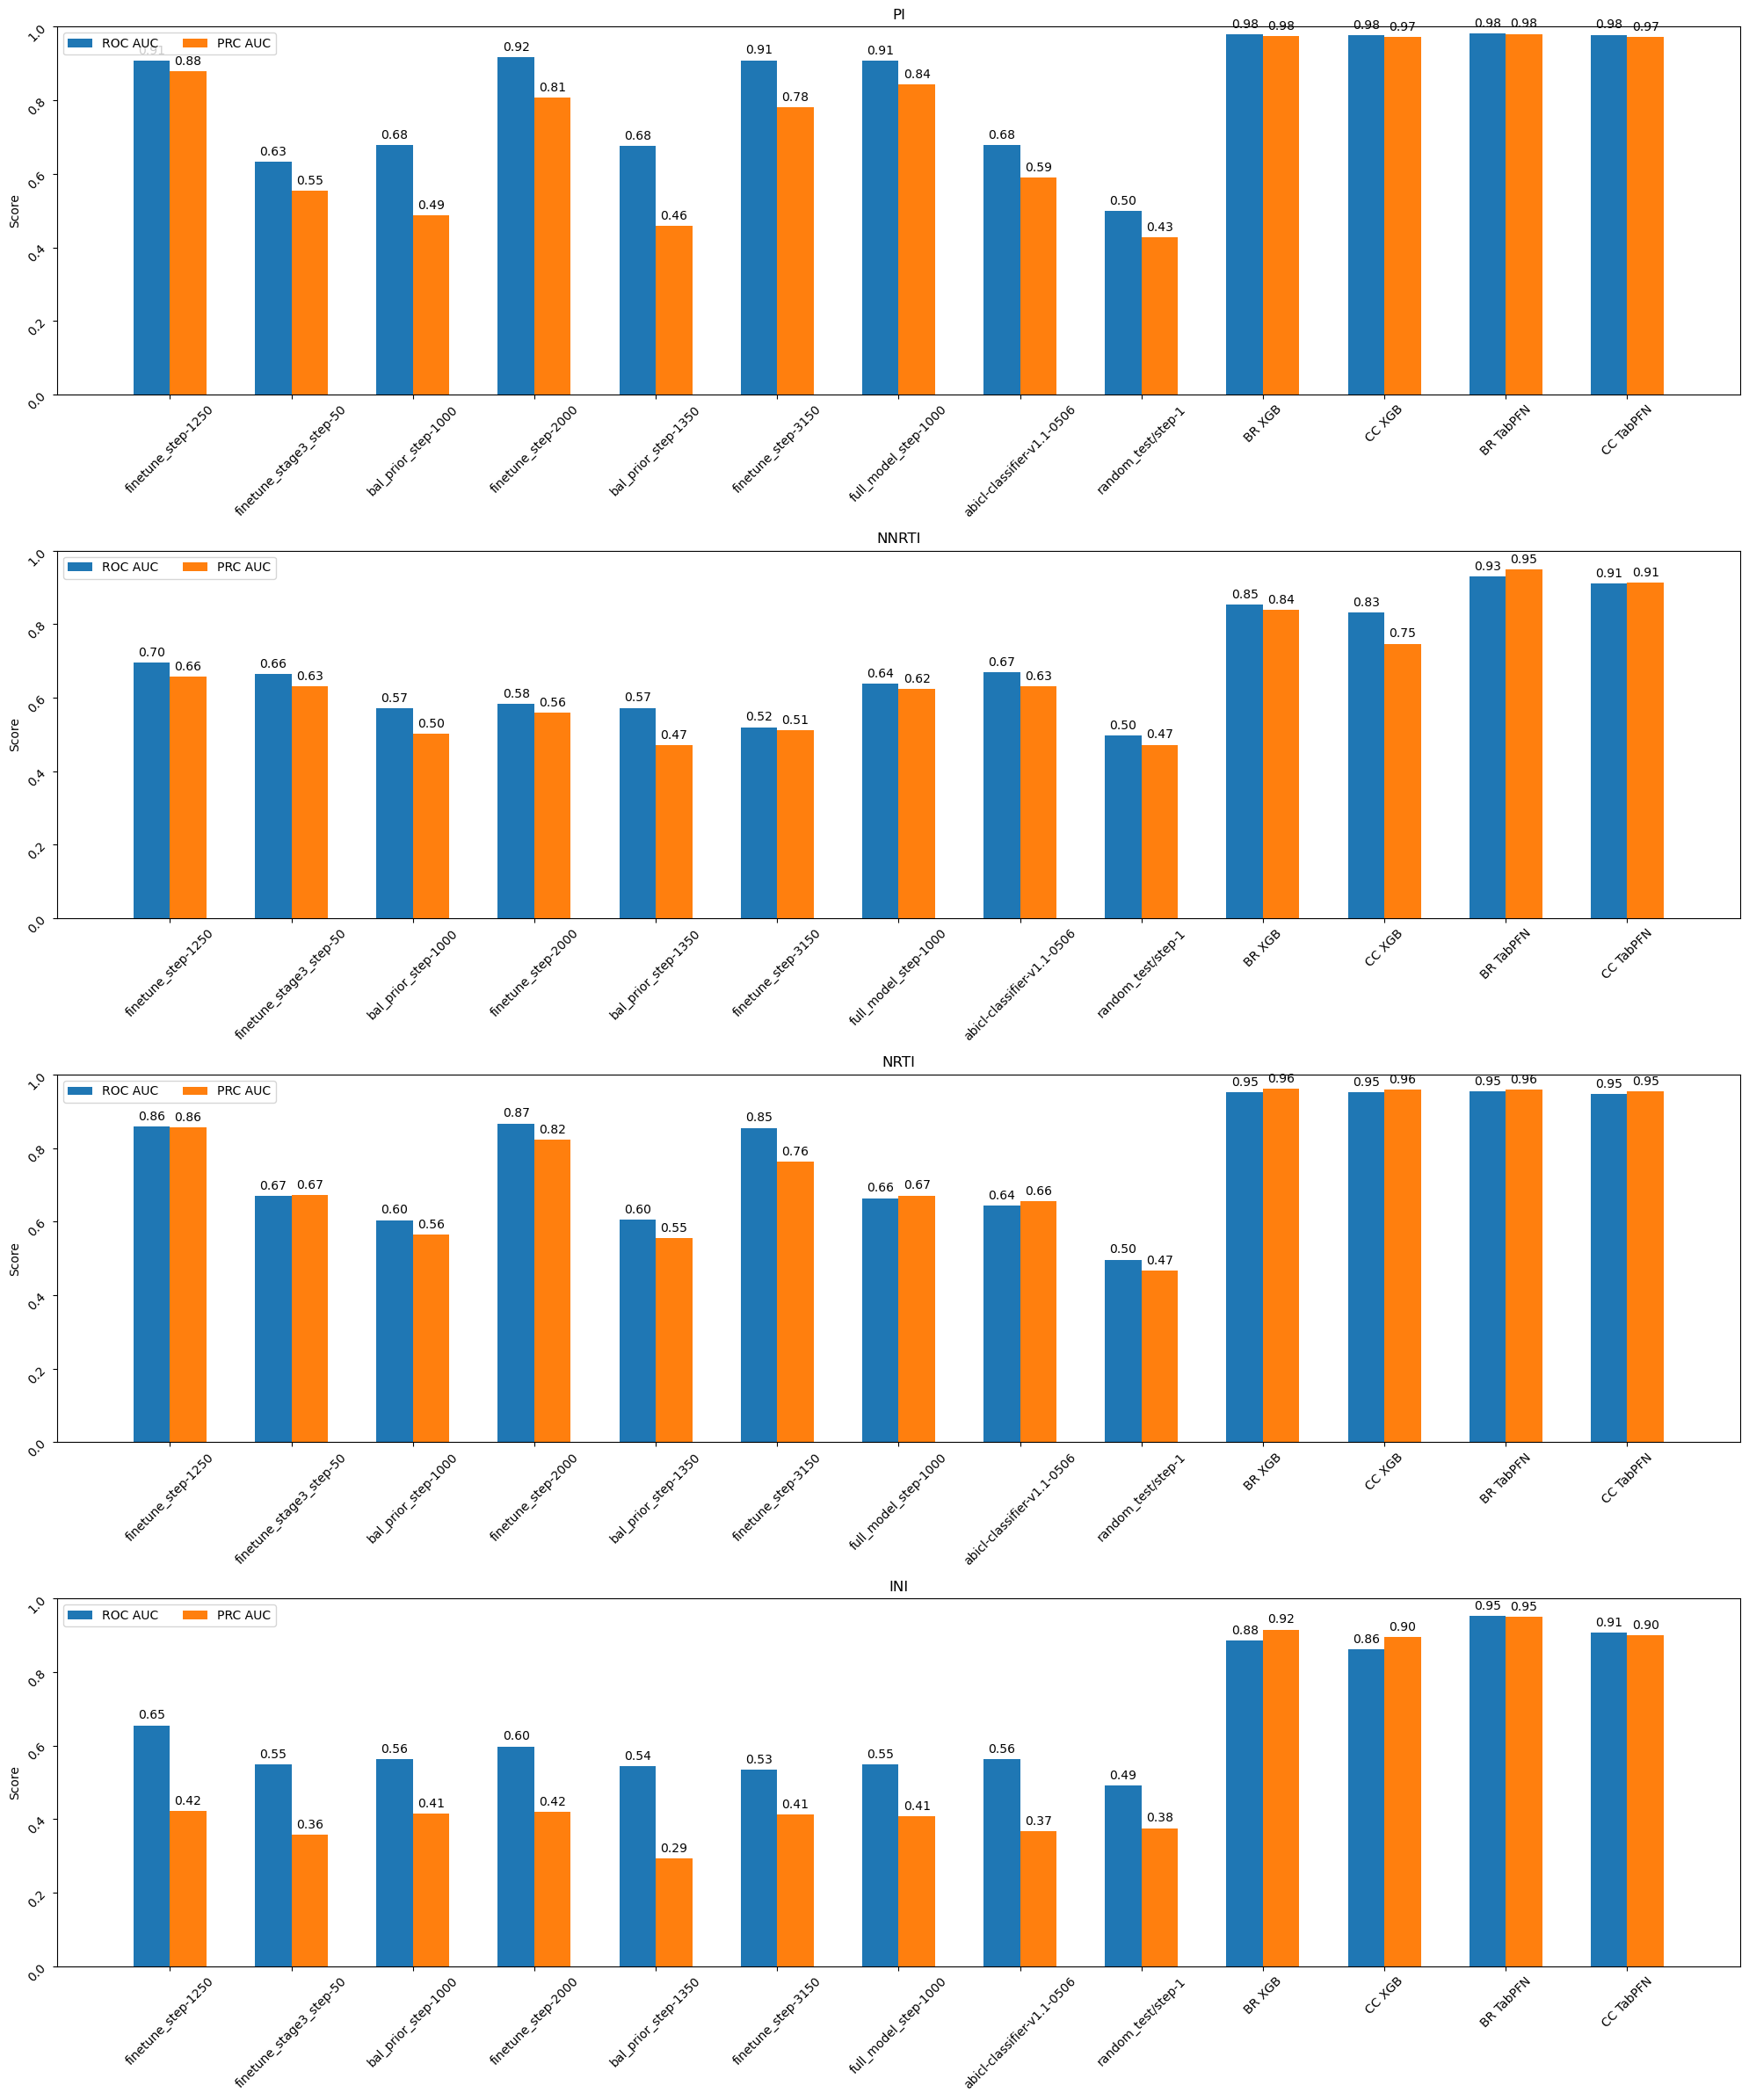

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler


modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_stage3_step-50",
    "bal_prior_step-1000",
    "finetune_step-2000",
    "bal_prior_step-1350",
    "finetune_step-3150",
    "full_model_step-1000",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]

ending = "_5_fold_scene_dataset.csv"

thrshlds_internal = {"finetune_step-1250":  0.6860411,
"bal_prior_step-1000":  0.5292327,
"finetune_step-2000":  0.747135,
"bal_prior_step-1350":  0.504576,
"finetune_step-3150":  0.67952967,
"full_model_step-1000":  0.581367369,
"abicl-classifier-v1.1-0506":  0.709058,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig = {"finetune_step-1250":  0.7540253,
"bal_prior_step-1000":  0.52958435,
"finetune_step-2000":  0.79760474,
"bal_prior_step-1350":  0.5100705,
"finetune_step-3150":  0.67292804,
"full_model_step-1000":  0.748620175,
"abicl-classifier-v1.1-0506":  0.7361159,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig_new = {"finetune_step-1250":  0.6830695,
"finetune_stage3_step-50":  0.62230235,
"bal_prior_step-1000":  0.53245866,
"finetune_step-2000":  0.721869,
"bal_prior_step-1350":  0.5226037,
"finetune_step-3150":  0.82249993,
"full_model_step-1000":  0.73285752,
"abicl-classifier-v1.1-0506":  0.7113368,
"random_test/step-1":  np.nan,}



results = []


path="../prediction_results/scene.csv_results/scene.csv_"



roc_auc = []
prc_auc = []
old_acc = []



print("============" + path.split("/")[-1].strip("_") + "============")

for model in models:

    print(model)

    pred = pd.read_csv(path + modeltype + model + ending)
    pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

    true_labels = pred.filter(regex="True_*")
    pred_labels_old = pred.filter(regex="Pred_*")
    pred_proba = pred_proba.filter(regex="Pred_*")
    #print(max(pred_proba.max()), min(pred_proba.min()))

    true_label_arr = np.array(true_labels)
    pred_proba_arr = np.array(pred_proba)

    roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
    prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))

    old_acc.append(result_handler.exam_acc(pred_labels_old, true_labels))




model_results= {"ROC AUC":roc_auc,
                             "PRC AUC":prc_auc,
                             "Base Acc": old_acc,}

results.append(model_results)


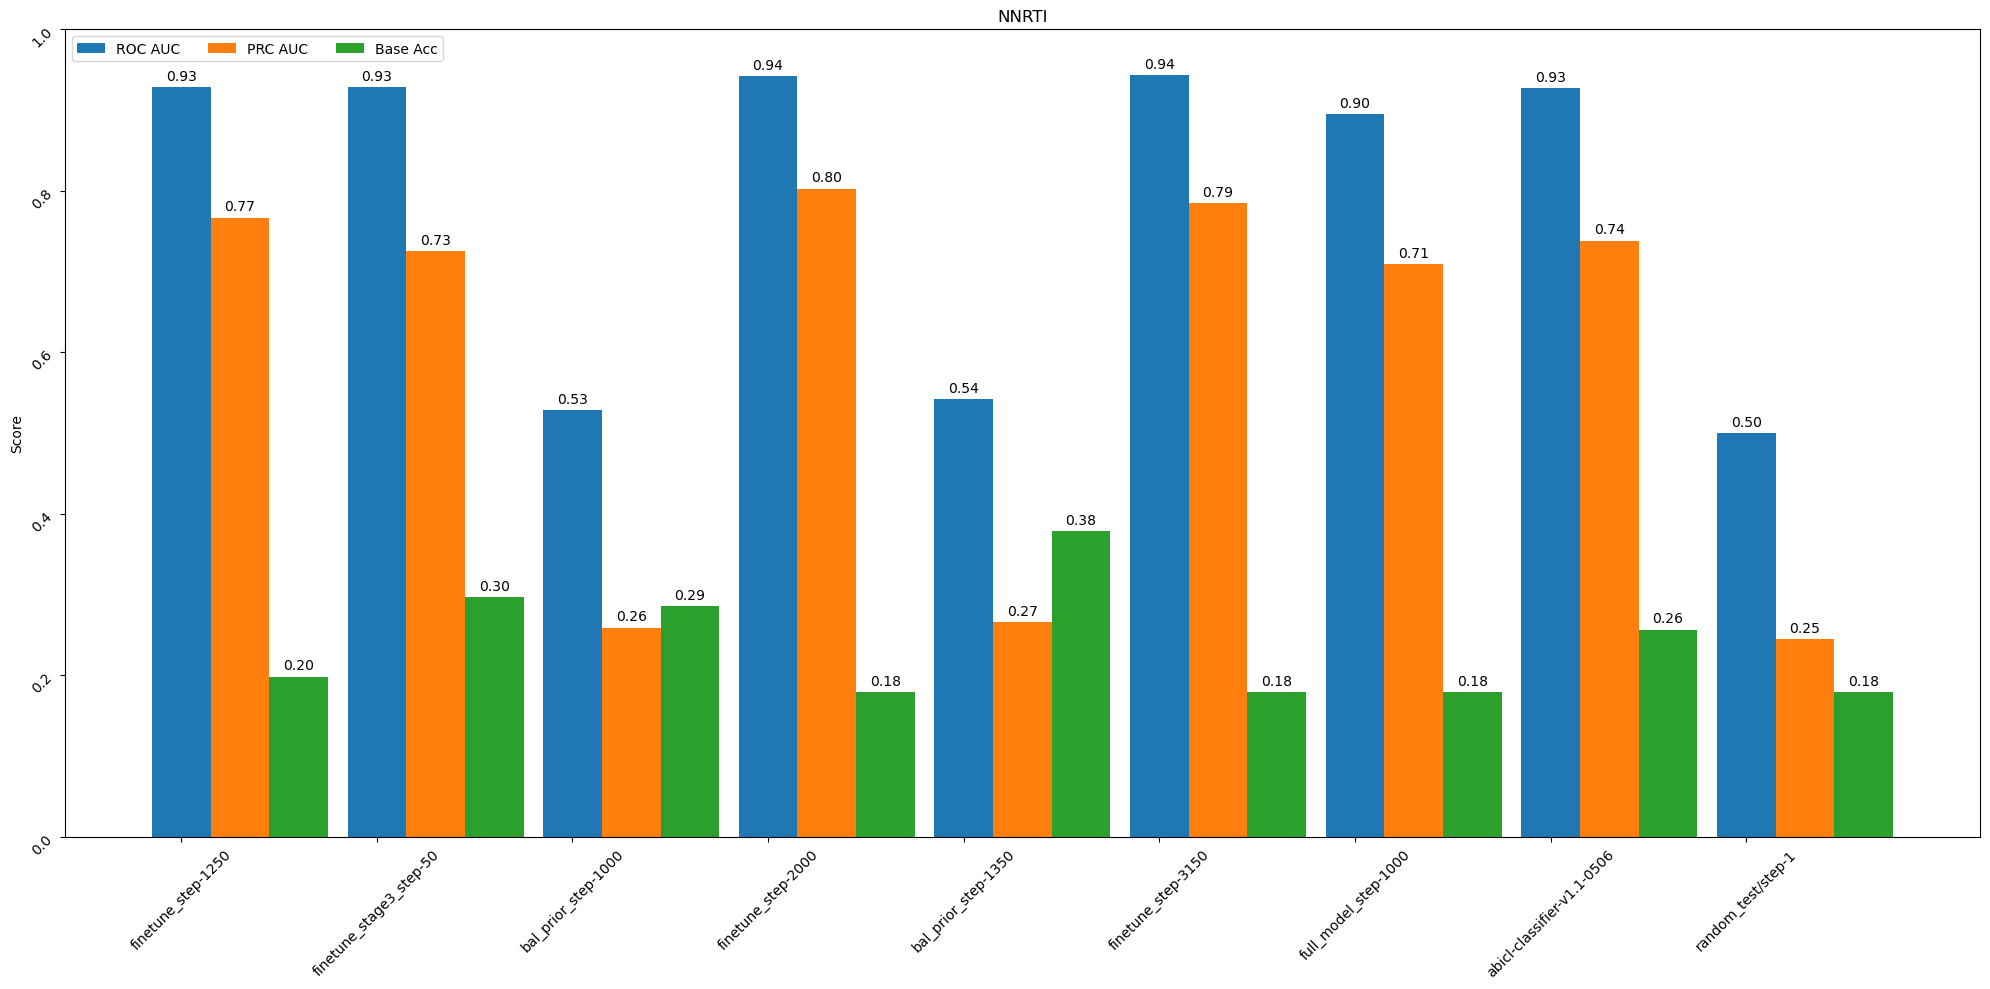

In [6]:

import numpy as np

x_ticks = models

x = np.arange(len(x_ticks))  # the label locations
width = 0.3  # the width of the bars

fig, axs = plt.subplots( figsize=(20, 10),layout='tight')


multiplier = 1.0

ax = axs

for attribute, measurement in results[0].items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, fmt='%.2f', padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title("scene")
ax.tick_params(rotation=45)
ax.set_xticks(x + width, x_ticks)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1)

plt.show()

============PI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
finetune_stage3_step-50
bal_prior_step-1000
bal_prior_step-1350
bal_prior_step-1700.ckpt
finetune_step-3150
full_model_step-1000
full_model_step-2900.ckpt
label_enc_step-1000.ckpt
label_enc_step-2300.ckpt
label_enc_step-4300.ckpt
cat_feat_step-1000.ckpt
cat_feat_step-3350.ckpt
zlpr_loss_step-300.ckpt
zlpr_loss_step-700.ckpt
abicl-classifier-v1.1-0506
random_test/step-1
../prediction_results/PI_results/benchmarkings/PI_BR_XGB_probabilities.csv
../prediction_results/PI_results/benchmarkings/PI_CC_XGB_probabilities.csv
../prediction_results/PI_results/PI_Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv
../prediction_results/PI_results/PI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv
============NNRTI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
finetune_stage3_step-50
bal_prior_step-1000
bal_prior_step-1350
bal_prior_ste

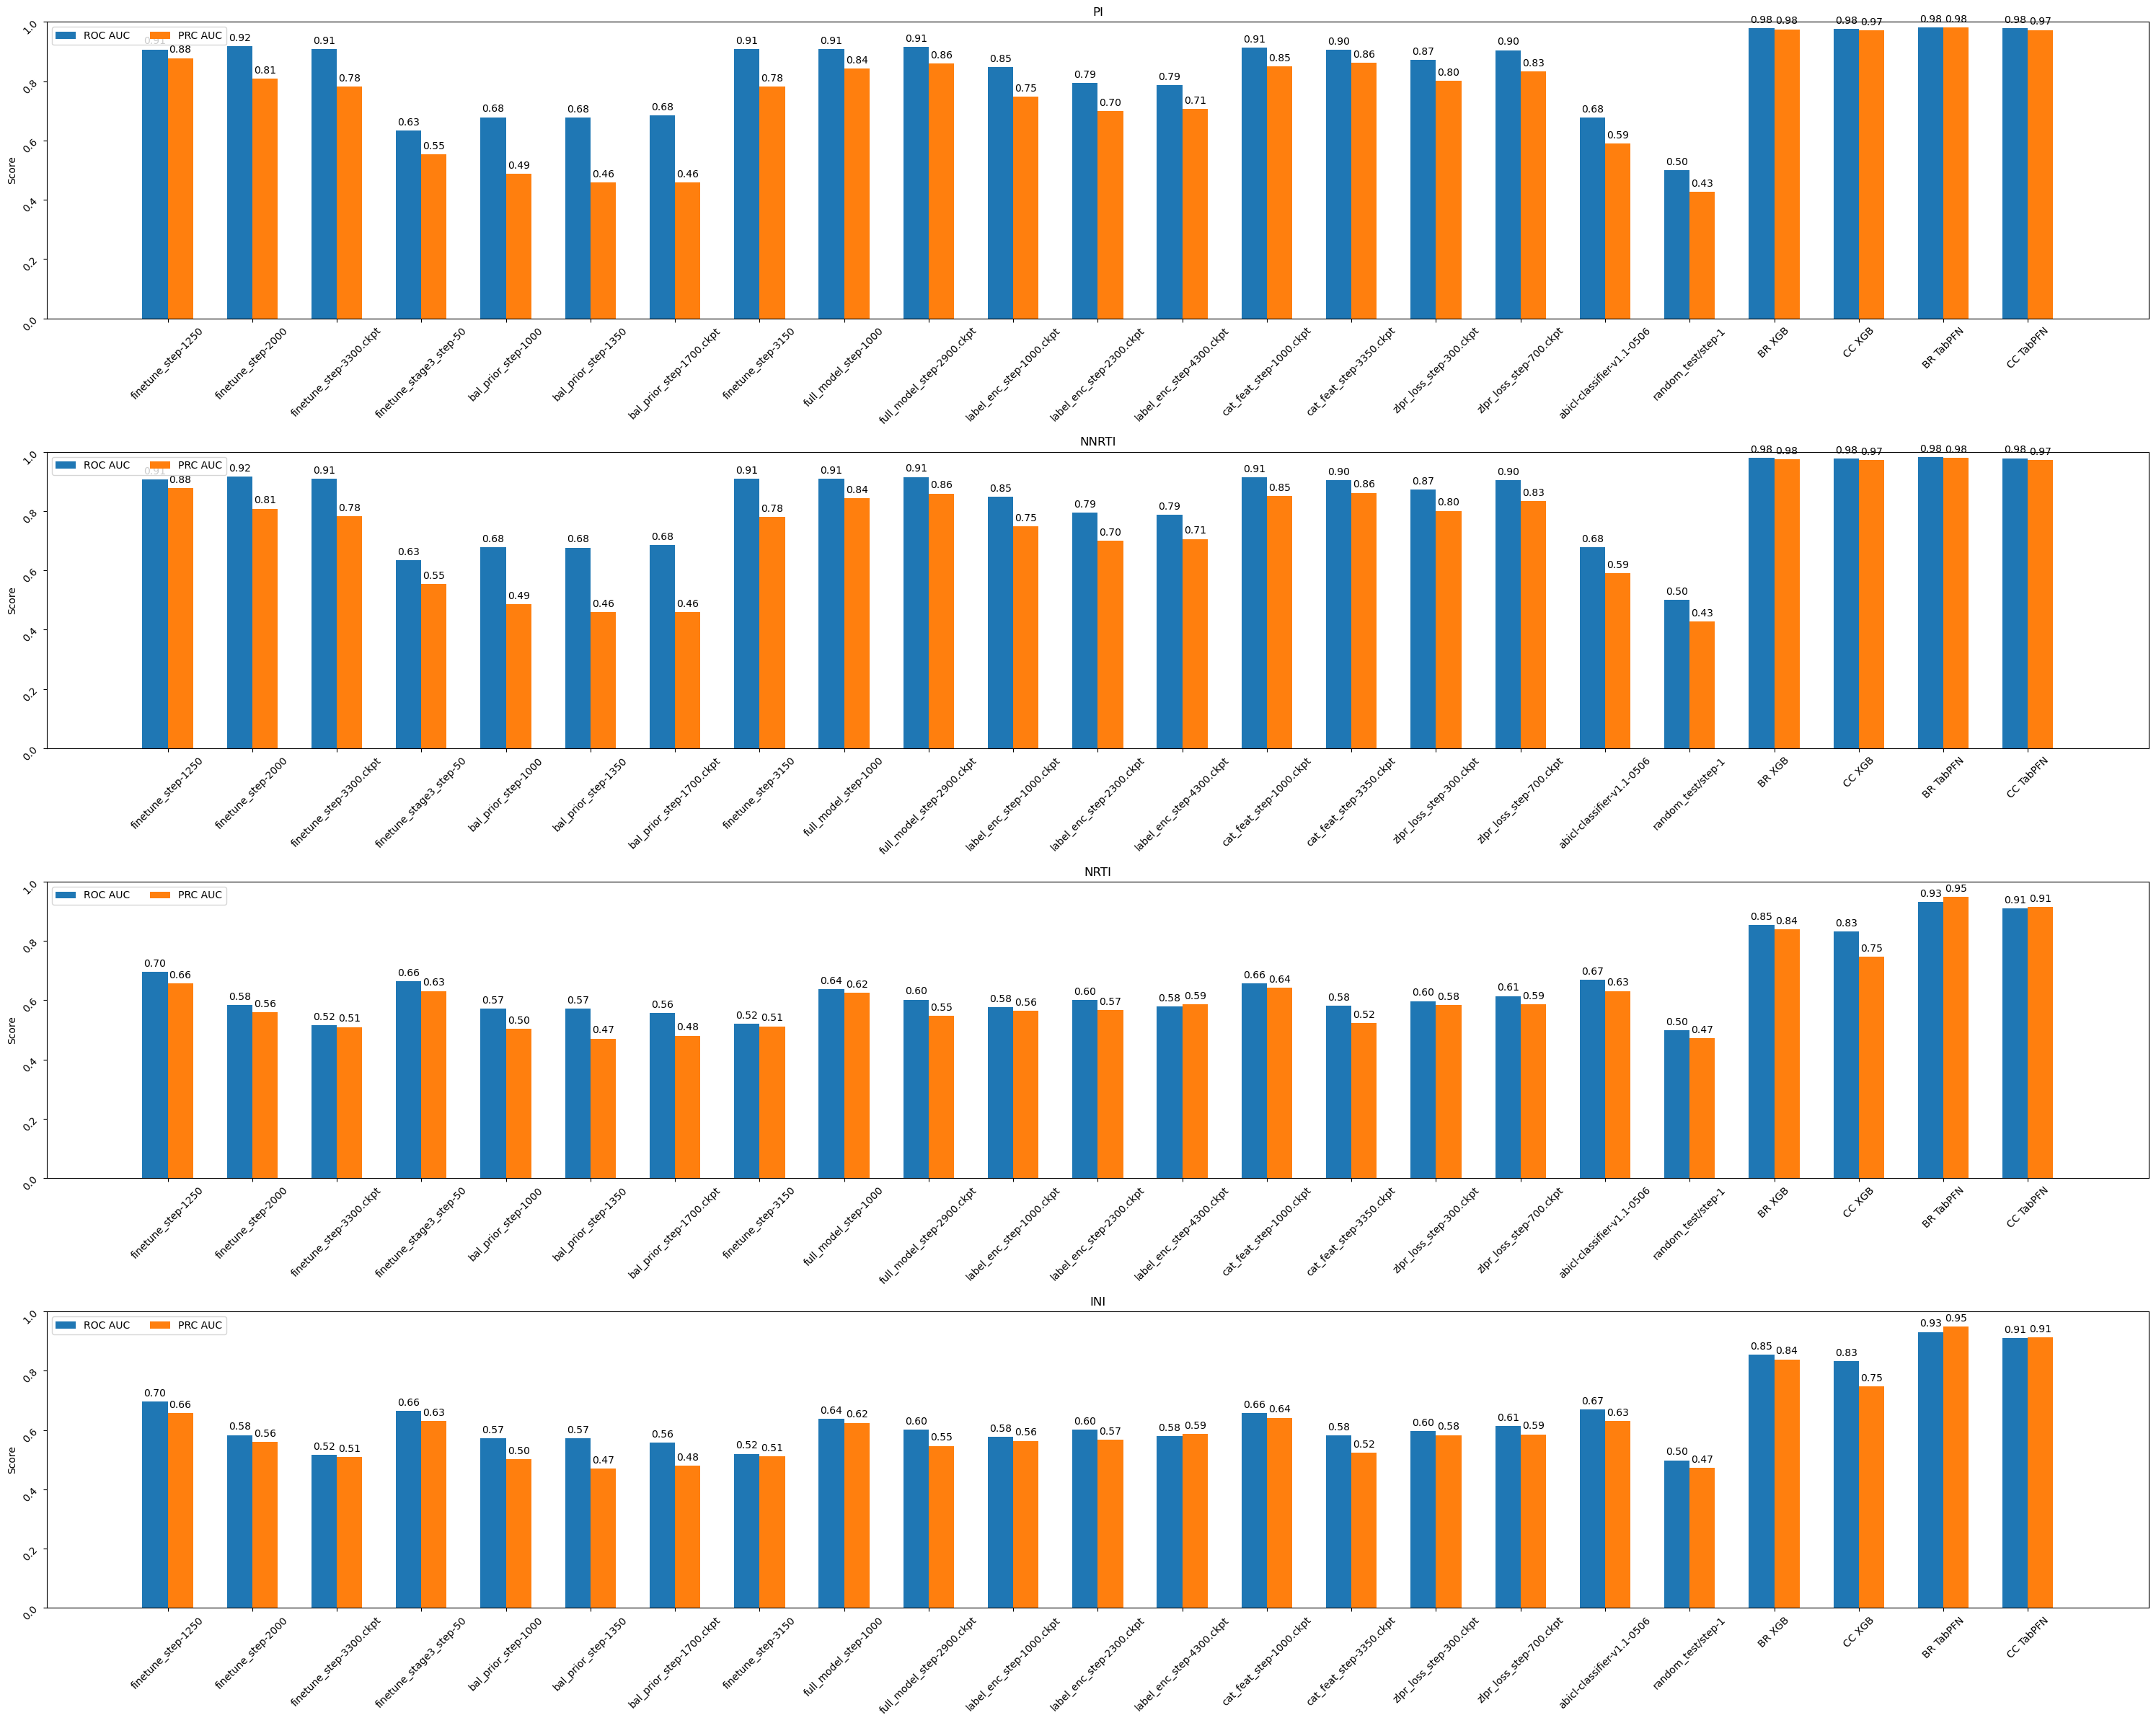

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
import re
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler


modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_step-2000",
    "finetune_step-3300.ckpt",
    "finetune_stage3_step-50",
    "bal_prior_step-1000",
    "bal_prior_step-1350",
    "bal_prior_step-1700.ckpt",
    "finetune_step-3150",
    "full_model_step-1000",
    "full_model_step-2900.ckpt",
    "label_enc_step-1000.ckpt",
    "label_enc_step-2300.ckpt",
    "label_enc_step-4300.ckpt",
    "cat_feat_step-1000.ckpt",
    "cat_feat_step-3350.ckpt",
    "zlpr_loss_step-300.ckpt",
    "zlpr_loss_step-700.ckpt",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]


results = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc = []
    prc_auc = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)




        pred = pd.read_csv(path + modeltype + model.strip(".ckpt") + ending)
        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + "_probabilities" + ending)


        true_labels = pred.filter(regex="True_*")
        pred_labels_old = pred.filter(regex="Pred_*")
        pred_proba = pred_proba.filter(regex="Pred_*")
        #print(max(pred_proba.max()), min(pred_proba.min()))

        true_label_arr = np.array(true_labels)
        pred_proba_arr = np.array(pred_proba)

        roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))





    model_results= {"ROC AUC":roc_auc,
                                 "PRC AUC":prc_auc}

    results.append(model_results)

    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = pred_proba.filter(regex="True_*")

        pred_proba = pred_proba.filter(regex="Pred_*")
        #print(max(pred_proba.max()), min(pred_proba.min()))

        true_label_arr = np.array(true_labels)
        pred_proba_arr = np.array(pred_proba)

        roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))


    model_results= {"ROC AUC":roc_auc,
                                 "PRC AUC":prc_auc}

    results.append(model_results)


x_ticks = models + ["BR XGB", "CC XGB", "BR TabPFN", "CC TabPFN"]

x = np.arange(len(x_ticks))  # the label locations
width = 0.3  # the width of the bars

fig, axs = plt.subplots(4, figsize=(30, 24),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = 0.5

    ax = axs[i]

    for attribute, measurement in results[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, fmt='%.2f', padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.tick_params(rotation=45)
    ax.set_xticks(x + width, x_ticks)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)

plt.show()



============PI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
finetune_stage3_step-50
bal_prior_step-1000
bal_prior_step-1350
bal_prior_step-1700.ckpt
finetune_step-3150
full_model_step-1000
full_model_step-2900.ckpt
label_enc_step-1000.ckpt
label_enc_step-2300.ckpt
label_enc_step-4300.ckpt
cat_feat_step-1000.ckpt
cat_feat_step-3350.ckpt
zlpr_loss_step-300.ckpt
zlpr_loss_step-700.ckpt
zlpr_loss_step-3050.ckpt
abicl-classifier-v1.1-0506
random_test/step-1
../prediction_results/PI_results/benchmarkings/PI_BR_XGB_probabilities.csv
../prediction_results/PI_results/benchmarkings/PI_CC_XGB_probabilities.csv
../prediction_results/PI_results/PI_Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv
../prediction_results/PI_results/PI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv
============NNRTI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
finetune_stage3_step-50
bal_prior_step-1000
bal_prio

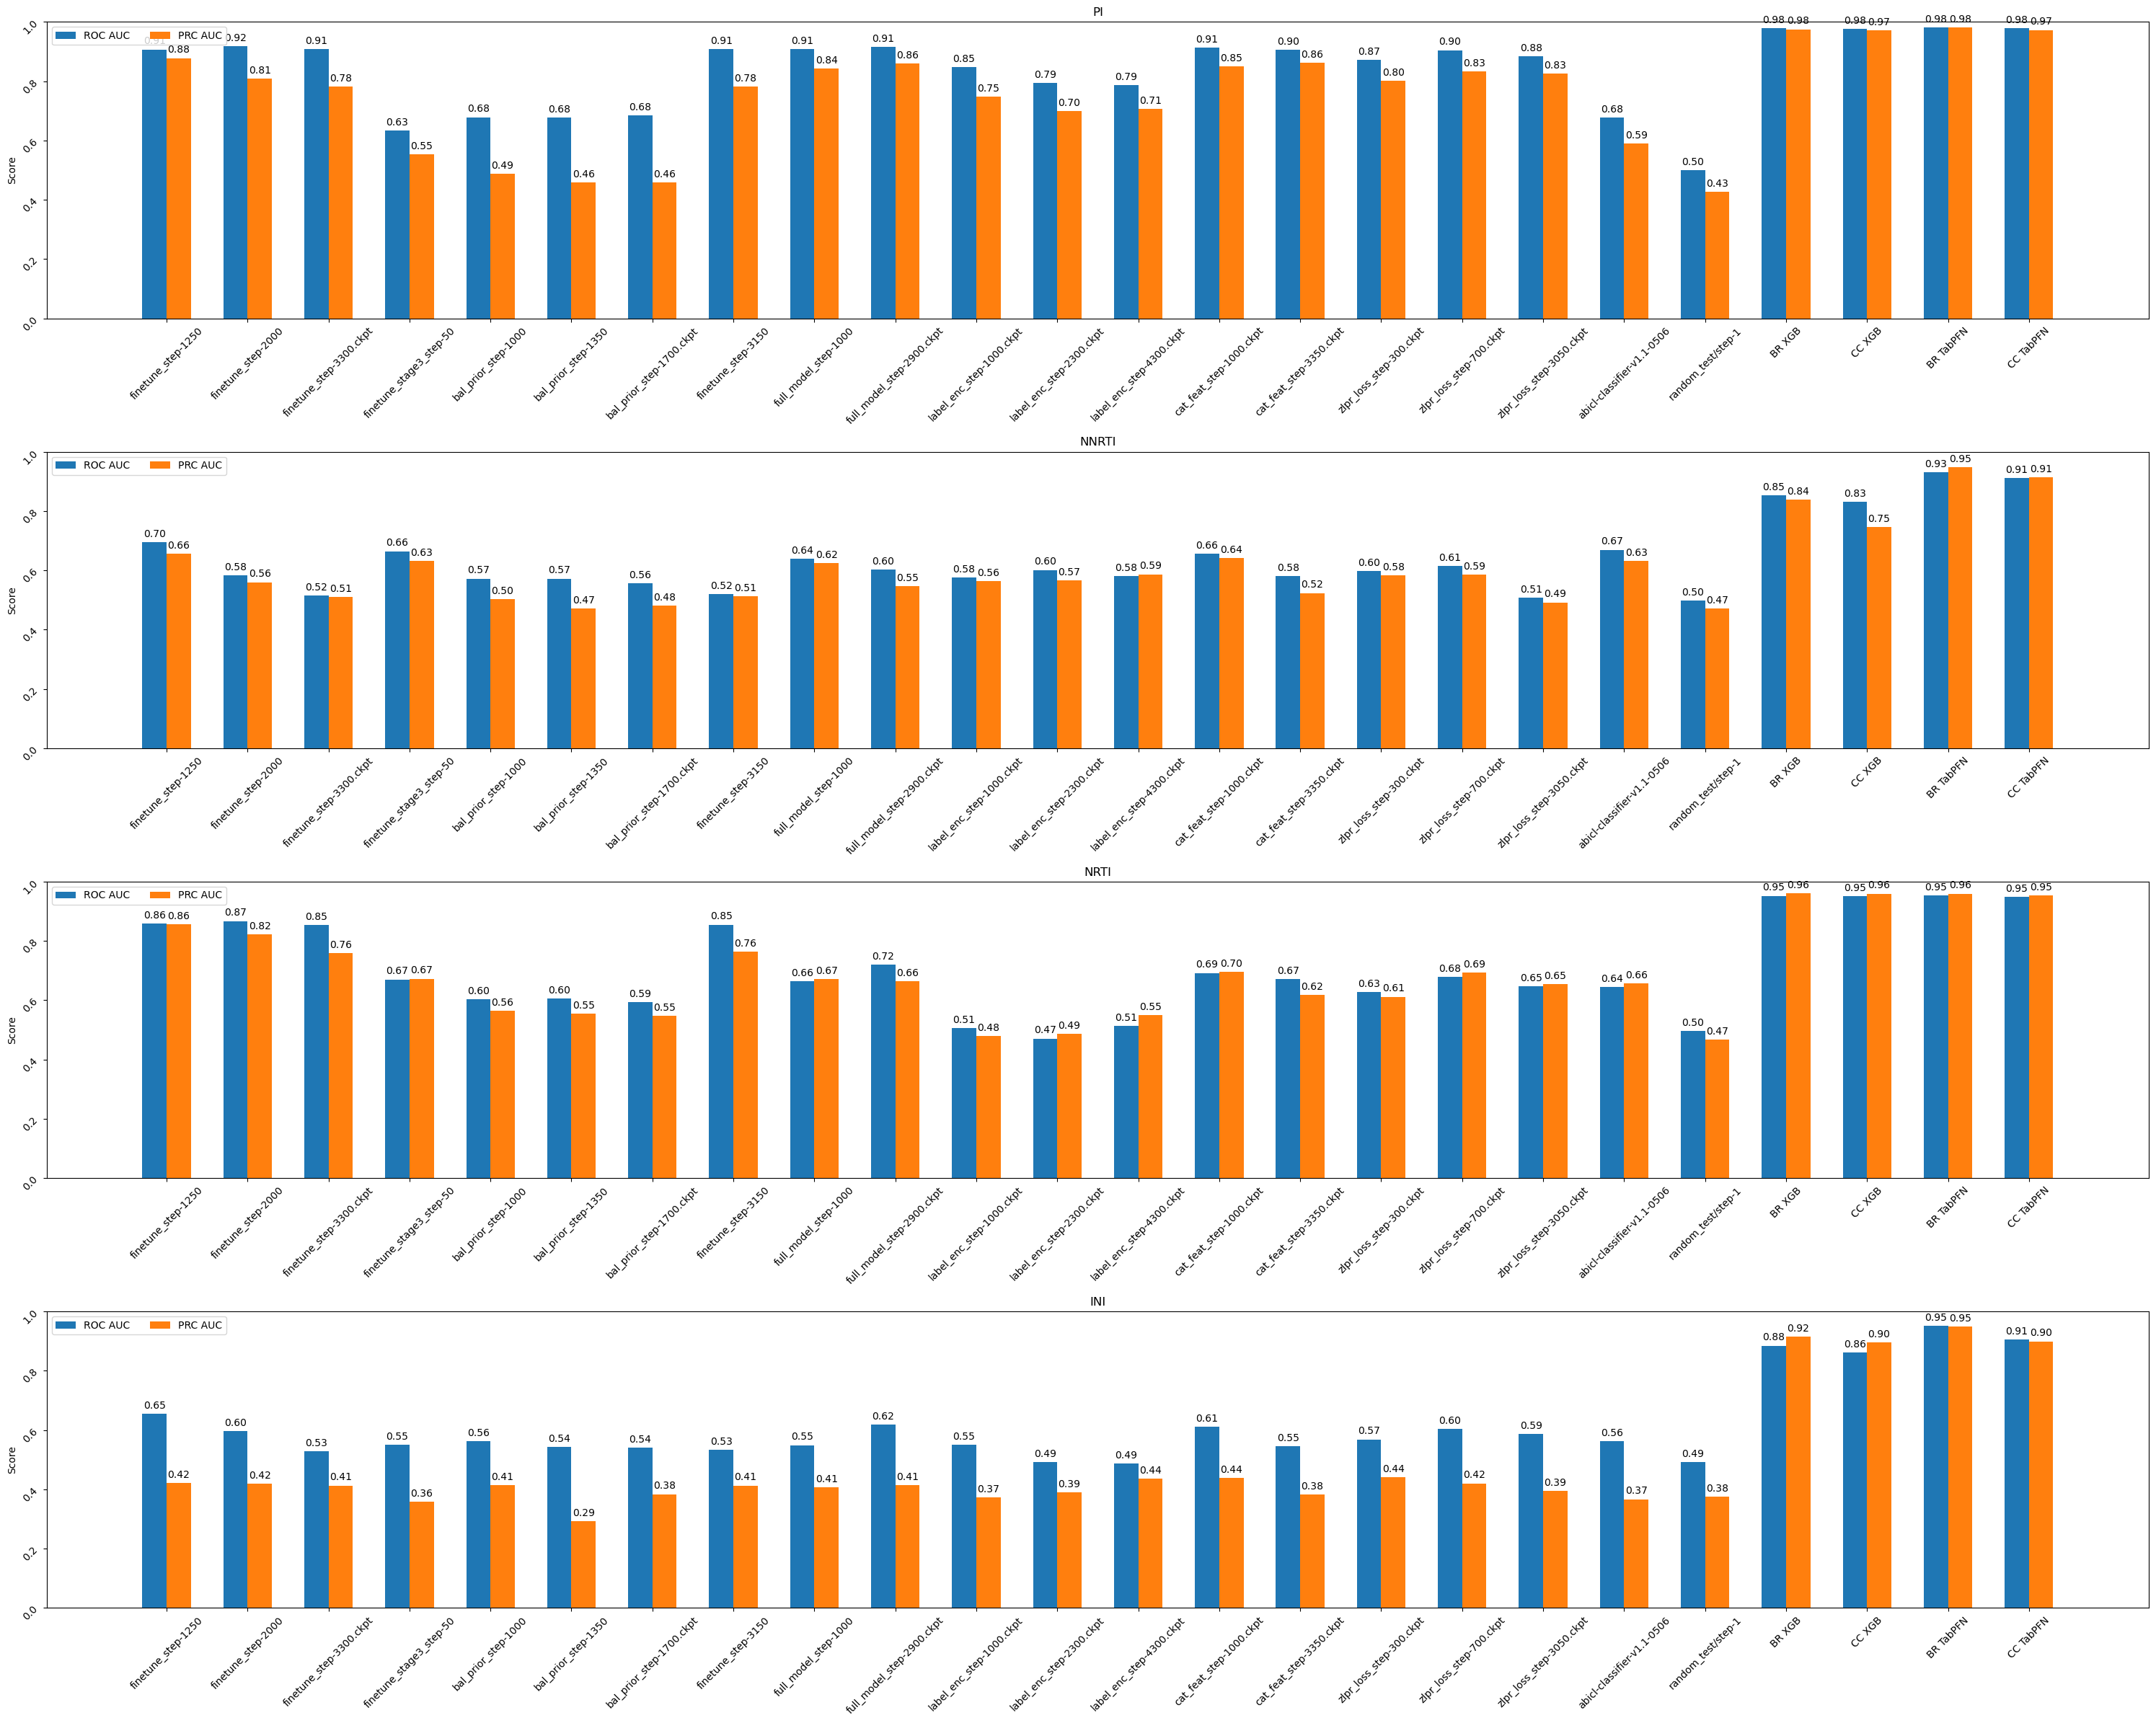

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
import re
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler


modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_step-2000",
    "finetune_step-3300.ckpt",
    "finetune_stage3_step-50",
    "bal_prior_step-1000",
    "bal_prior_step-1350",
    "bal_prior_step-1700.ckpt",
    "finetune_step-3150",
    "full_model_step-1000",
    "full_model_step-2900.ckpt",
    "label_enc_step-1000.ckpt",
    "label_enc_step-2300.ckpt",
    "label_enc_step-4300.ckpt",
    "cat_feat_step-1000.ckpt",
    "cat_feat_step-3350.ckpt",
    "zlpr_loss_step-300.ckpt",
    "zlpr_loss_step-700.ckpt",
    "zlpr_loss_step-3050.ckpt",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]


results = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc = []
    prc_auc = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)




        pred = pd.read_csv(path + modeltype + model.strip(".ckpt") + ending)
        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + "_probabilities" + ending)


        true_labels = pred.filter(regex="True_*")
        pred_labels_old = pred.filter(regex="Pred_*")
        pred_proba = pred_proba.filter(regex="Pred_*")
        #print(max(pred_proba.max()), min(pred_proba.min()))

        true_label_arr = np.array(true_labels)
        pred_proba_arr = np.array(pred_proba)

        roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))





    #model_results= {"ROC AUC":roc_auc,
    #                             "PRC AUC":prc_auc}

    #results.append(model_results)

    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = pred_proba.filter(regex="True_*")

        pred_proba = pred_proba.filter(regex="Pred_*")
        #print(max(pred_proba.max()), min(pred_proba.min()))

        true_label_arr = np.array(true_labels)
        pred_proba_arr = np.array(pred_proba)

        roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))


    model_results= {"ROC AUC":roc_auc,
                                 "PRC AUC":prc_auc}

    results.append(model_results)


x_ticks = models + ["BR XGB", "CC XGB", "BR TabPFN", "CC TabPFN"]

x = np.arange(len(x_ticks))  # the label locations
width = 0.3  # the width of the bars

fig, axs = plt.subplots(4, figsize=(30, 24),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = 0.5

    ax = axs[i]

    for attribute, measurement in results[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, fmt='%.2f', padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.tick_params(rotation=45)
    ax.set_xticks(x + width, x_ticks)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)

plt.show()



In [11]:
print(results)

[{'ROC AUC': [0.9071722218447218, 0.9170794693648017, 0.9084780905092836, 0.63313699277589, 0.6784114559541663, 0.6766394962961199, 0.6849359926157059, 0.9085250241189418, 0.9078545108651965, 0.9148624004135162, 0.8484549482100439, 0.7949452894188741, 0.7872041709164431, 0.9136433109436313, 0.9048798734542489, 0.8718392534801711, 0.9046314321255519, 0.677915555592626, 0.4997526786059179, 0.9787579399352748, 0.9766773378305513, 0.981353360950148, 0.9779292708733489], 'PRC AUC': [0.8778454771534869, 0.8078523911599329, 0.7827848835515979, 0.5535139663802927, 0.48682559437742956, 0.45836680992972223, 0.4588651457934093, 0.7809155242212762, 0.8423899925145605, 0.859081269978127, 0.7473949633846559, 0.6989000565743012, 0.7059490044046035, 0.8504354553838112, 0.8612919704813785, 0.8005346922645787, 0.8325271784010377, 0.5897388591209786, 0.4275192740590603, 0.9750517729724684, 0.9719582599496165, 0.9802975909314836, 0.9727012915198207]}, {'ROC AUC': [0.9071722218447218, 0.9170794693648017, 0

============PI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
finetune_stage3_step-50
bal_prior_step-1000
bal_prior_step-1350
bal_prior_step-1700.ckpt
finetune_step-3150
full_model_step-1000
full_model_step-2900.ckpt
label_enc_step-1000.ckpt
label_enc_step-2300.ckpt
label_enc_step-4300.ckpt
cat_feat_step-1000.ckpt
cat_feat_step-3350.ckpt
zlpr_loss_step-300.ckpt
zlpr_loss_step-700.ckpt
zlpr_loss_step-3050.ckpt
abicl-classifier-v1.1-0506
random_test/step-1
../prediction_results/PI_results/PI_Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv
../prediction_results/PI_results/PI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv
============NNRTI============
finetune_step-1250
finetune_step-2000
finetune_step-3300.ckpt
finetune_stage3_step-50
bal_prior_step-1000
bal_prior_step-1350
bal_prior_step-1700.ckpt
finetune_step-3150
full_model_step-1000
full_model_step-2900.ckpt
label_enc_step-1000.ckpt
label_enc_step-2300.ck

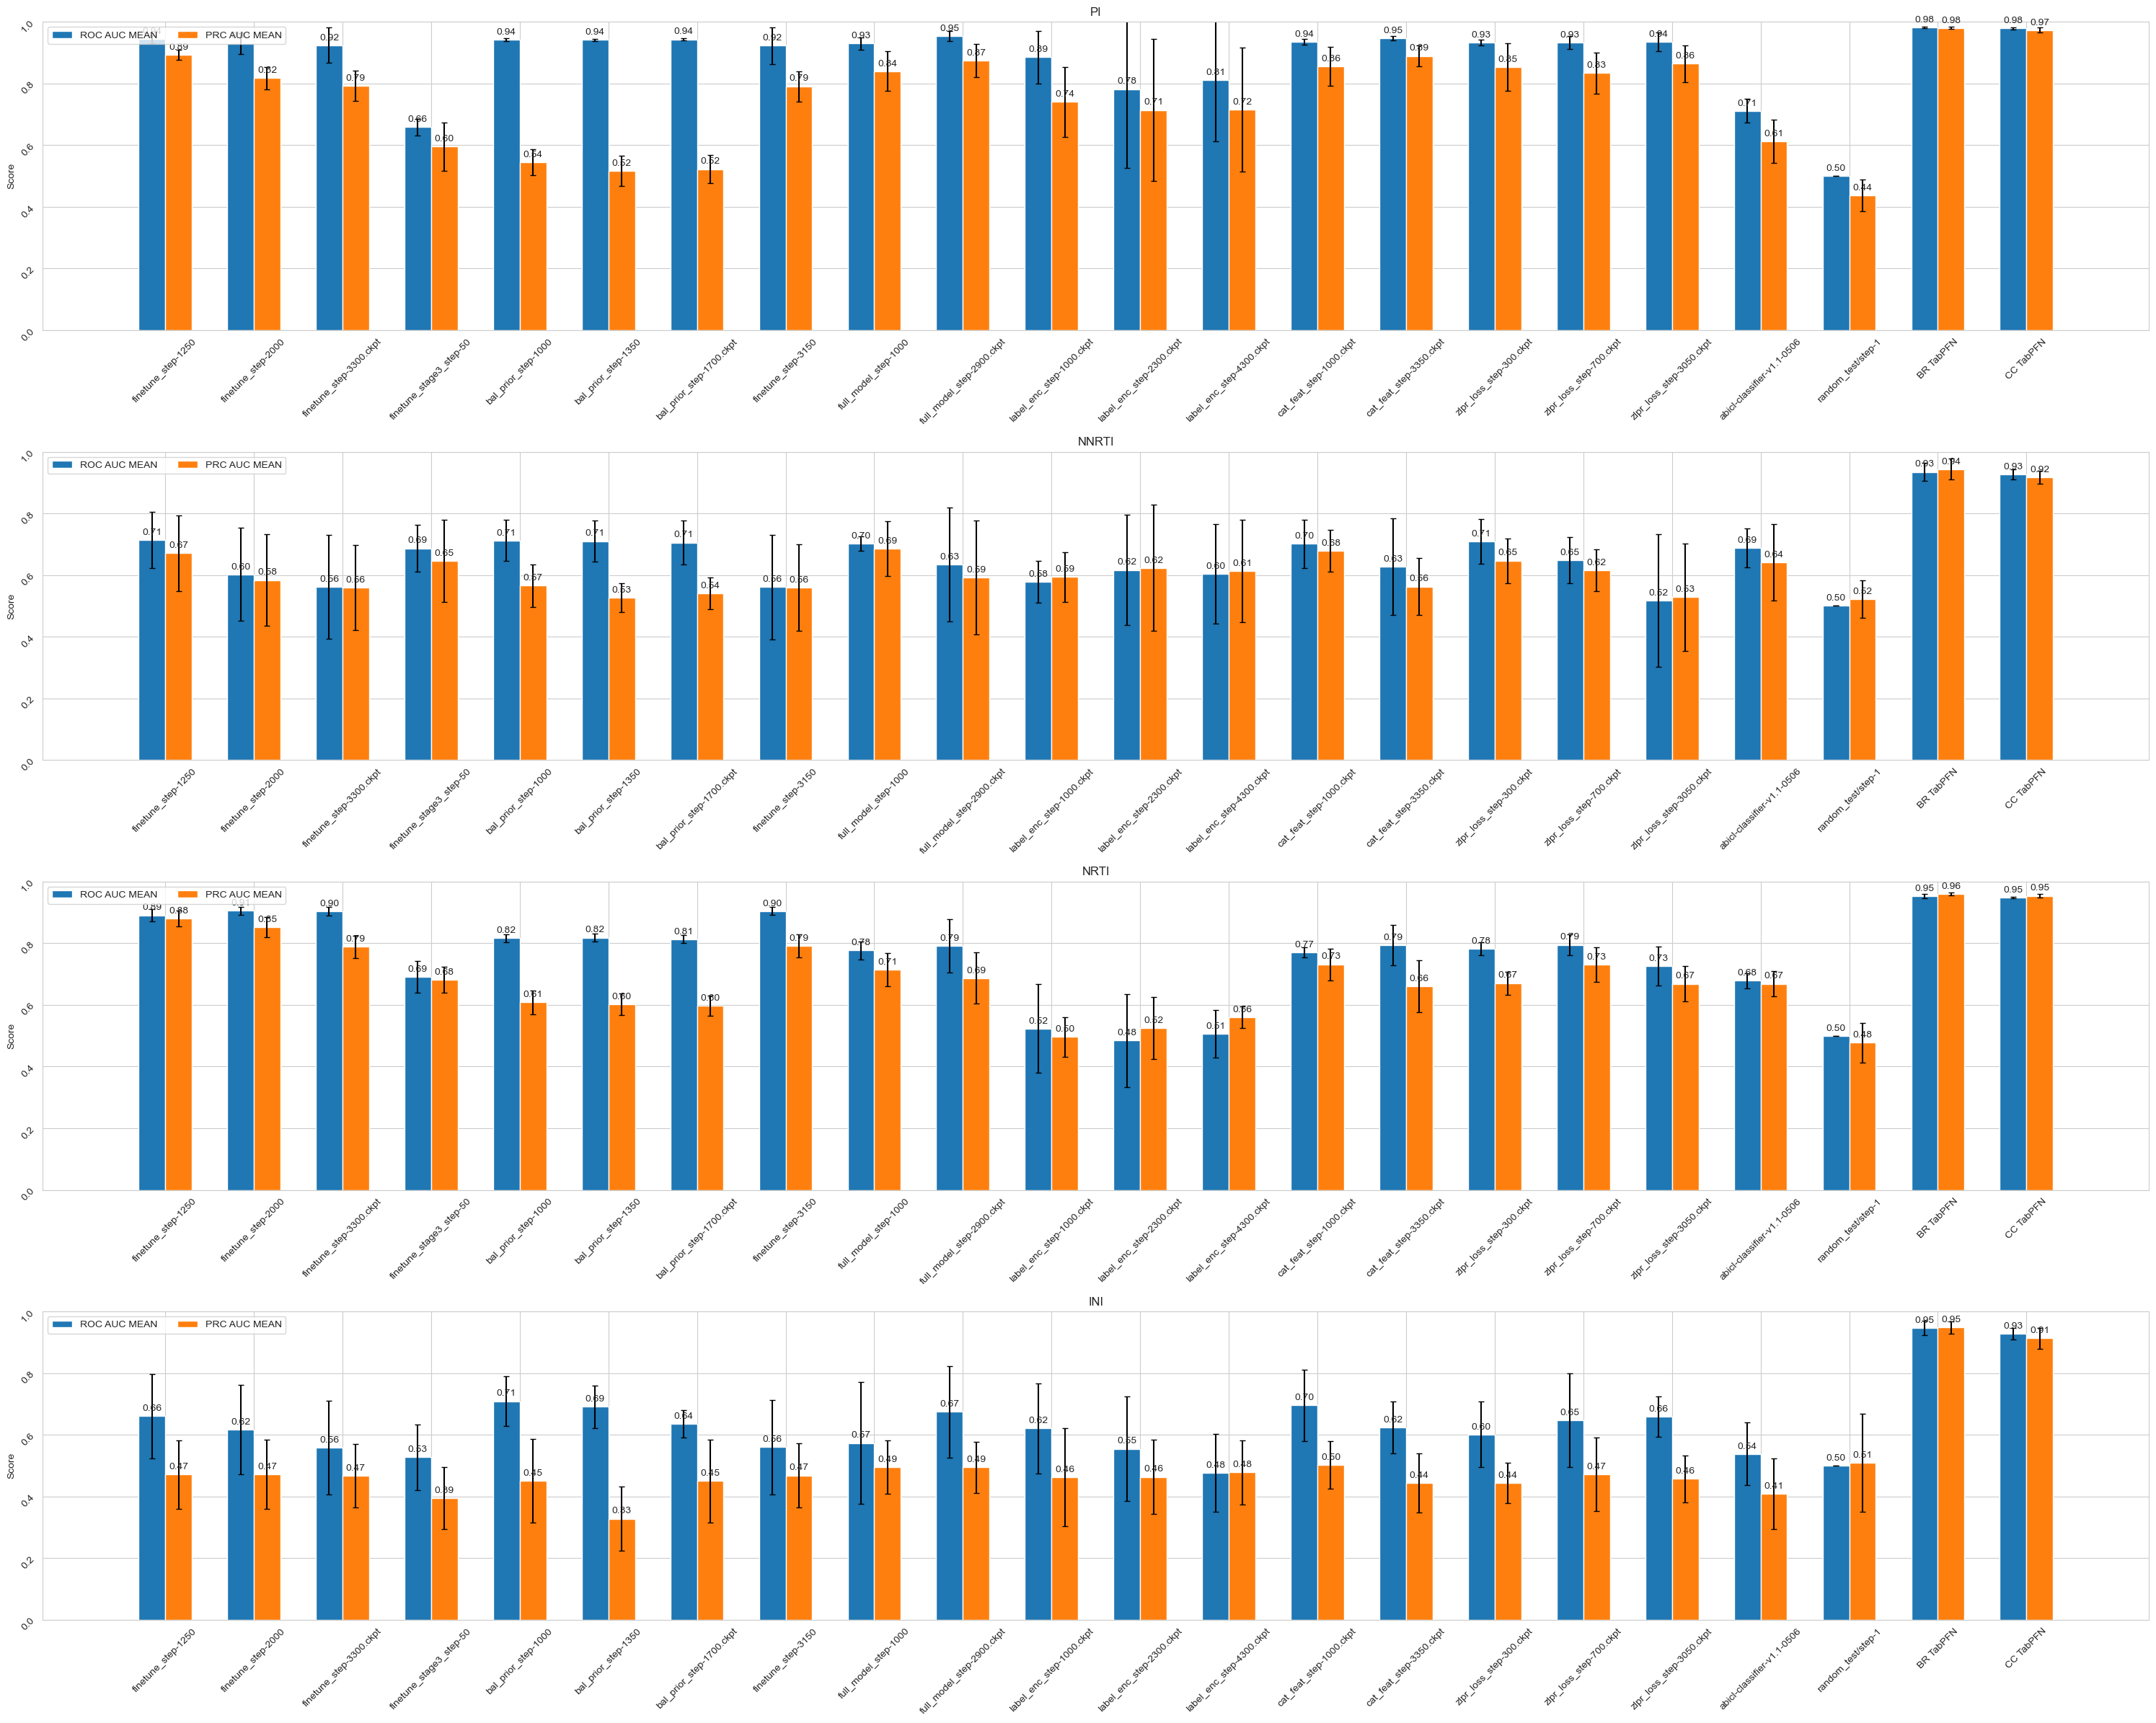

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
import re
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler

#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_step-2000",
    "finetune_step-3300.ckpt",
    "finetune_stage3_step-50",
    "bal_prior_step-1000",
    "bal_prior_step-1350",
    "bal_prior_step-1700.ckpt",
    "finetune_step-3150",
    "full_model_step-1000",
    "full_model_step-2900.ckpt",
    "label_enc_step-1000.ckpt",
    "label_enc_step-2300.ckpt",
    "label_enc_step-4300.ckpt",
    "cat_feat_step-1000.ckpt",
    "cat_feat_step-3350.ckpt",
    "zlpr_loss_step-300.ckpt",
    "zlpr_loss_step-700.ckpt",
    "zlpr_loss_step-3050.ckpt",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]


results_mean = []
results_std = []

ending = "_5_fold_new_loss_sigmoid.csv"

#path="../prediction_results/scene.csv_results/scene.csv_"

for path in filepath_list:

    roc_auc_mean = []
    roc_auc_std = []
    prc_auc_mean = []
    prc_auc_std = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred_proba = pd.read_csv(path + modeltype + model.strip(".ckpt") + "_probabilities" + ending)



        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

        #roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        #prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))


    benchmark_prefix = re.sub('[^/]+_$', '', path) + "benchmarkings/" + path.split("/")[-1]

    #comp_mod = [benchmark_prefix + "BR_XGB_probabilities.csv", benchmark_prefix + "CC_XGB_probabilities.csv", path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    comp_mod = [path + "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", path + "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

    for model in comp_mod:

        print(model)


        pred_proba = pd.read_csv(model)

        pred_proba.dropna(subset=pred_proba.columns[pred_proba.columns.str.startswith('True_')].tolist(), inplace=True)


        roc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: roc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*"))), include_groups=False)
        prc_auc = pred_proba.groupby(by="kFolds").apply(lambda x: result_handler.prc_auc_score(np.array(x.filter(regex="True_*")), np.array(x.filter(regex="Pred_*")), multiclass="ovr"), include_groups=False)


        roc_auc_mean.append(roc_auc.mean())
        roc_auc_std.append(roc_auc.std())

        prc_auc_mean.append(prc_auc.mean())
        prc_auc_std.append(prc_auc.std())

    '''
    model_results= {"ROC AUC MEAN":roc_auc_mean,
                    "ROC AUC STD":roc_auc_std,
                    "PRC AUC MEAN":prc_auc_mean,
                    "PRC AUC STD":prc_auc_std}
    '''

    results_mean.append({"ROC AUC MEAN":roc_auc_mean,
                    "PRC AUC MEAN":prc_auc_mean})

    results_std.append({"ROC AUC STD":roc_auc_std,
                    "PRC AUC STD":prc_auc_std})


x_ticks = models + ["BR TabPFN", "CC TabPFN"]

x = np.arange(len(x_ticks))  # the label locations
width = 0.3  # the width of the bars

fig, axs = plt.subplots(4, figsize=(30, 24),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = 0.5

    ax = axs[i]

    for attribute, measurement in results_mean[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        print(results_std[i][attribute.strip("MEAN") + "STD"])
        ax.errorbar(x + offset, measurement, yerr=results_std[i][attribute.strip("MEAN") + "STD"],capsize=3, fmt="none", ecolor="black")
        ax.bar_label(rects, fmt='%.2f', padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.tick_params(rotation=45)
    ax.set_xticks(x + width, x_ticks)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)

plt.show()

